In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# 1. READ THE FILE
# Replace the path with your actual new file path
file_path = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"
with h5py.File(file_path, 'r') as f:
    # Assuming 'frb' is the main group based on your previous output
    data = f['frb'] 
    wfall_raw = data['wfall'][:]
    # We create the spectrum from the raw data
    spec = np.nanmean(wfall_raw, axis=1)

# 2. PREPARE THE MASKED VERSION
wfall_masked = wfall_raw.copy()

# 3. RFI MASKING LOGIC
q1 = np.nanquantile(spec, 0.25)
q3 = np.nanquantile(spec, 0.75)
iqr = q3 - q1
rfi_masking_var_factor = 3

channel_variance = np.nanvar(wfall_masked, axis=1)
mean_channel_variance = np.nanmean(channel_variance)

# Create masks separately to prevent broadcasting errors
channel_mask = (channel_variance > rfi_masking_var_factor * mean_channel_variance)
time_mask = (spec[::-1] < q1 - 1.5 * iqr) | (spec[::-1] > q3 + 1.5 * iqr)

# Apply masks
wfall_masked[channel_mask, :] = np.nan
wfall_masked[:, time_mask] = np.nan

# 4. VISUALIZE BOTH
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].imshow(wfall_raw, aspect='auto', origin='lower', interpolation='none')
axs[0].set_title("Raw Data (Original)")

axs[1].imshow(wfall_masked, aspect='auto', origin='lower', interpolation='none')
axs[1].set_title("RFI Masked Data")

plt.show()

/tmp/ipykernel_29078/2276093825.py:13: RuntimeWarning: Mean of empty slice
  spec = np.nanmean(wfall_raw, axis=1)
/tmp/ipykernel_29078/2276093825.py:24: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall_masked, axis=1)


IndexError: boolean index did not match indexed array along dimension 1; dimension is 38 but corresponding boolean dimension is 16384

/tmp/ipykernel_29078/268216377.py:5: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall_masked, axis=1)


/tmp/ipykernel_29078/1909247956.py:12: RuntimeWarning: Mean of empty slice
  spec = np.nanmean(wfall_raw, axis=1)
/tmp/ipykernel_29078/1909247956.py:26: RuntimeWarning: Degrees of freedom <= 0 for slice.
  channel_variance = np.nanvar(wfall_masked, axis=1)


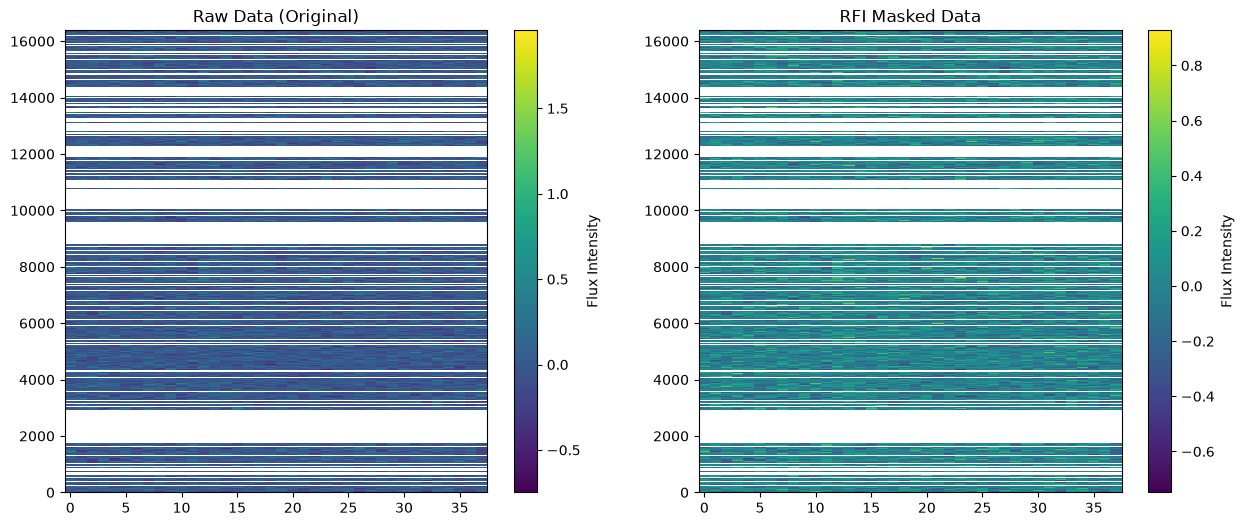

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# 1. READ THE FILE
file_path =  r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images/FRB20180725A_waterfall.h5"

with h5py.File(file_path, 'r') as f:
    data = f['frb'] 
    wfall_raw = data['wfall'][:]
    # Calculate spec from the raw data
    spec = np.nanmean(wfall_raw, axis=1)

# 2. PREPARE FOR MASKING
wfall_masked = wfall_raw.copy()
n_channels, n_time = wfall_masked.shape

# 3. MASKING PARAMETERS
q1 = np.nanquantile(spec, 0.25)
q3 = np.nanquantile(spec, 0.75)
iqr = q3 - q1
rfi_masking_var_factor = 3

# 4. GENERATE MASKS
# Variance mask for frequency channels
channel_variance = np.nanvar(wfall_masked, axis=1)
mean_channel_variance = np.nanmean(channel_variance)
channel_mask = (channel_variance > rfi_masking_var_factor * mean_channel_variance)

# Time mask for time samples (dynamically scaled to n_time)
spec_slice = spec[:n_time]
time_mask = (spec_slice[::-1] < q1 - 1.5 * iqr) | (spec_slice[::-1] > q3 + 1.5 * iqr)

# 5. APPLY MASKS
wfall_masked[channel_mask, :] = np.nan
wfall_masked[:, time_mask] = np.nan

# 6. VISUALIZE
'''fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].imshow(wfall_raw, aspect='auto', origin='lower', interpolation='none')
axs[0].set_title("Raw Data (Original)")

axs[1].imshow(wfall_masked, aspect='auto', origin='lower', interpolation='none')
axs[1].set_title("RFI Masked Data")

plt.show()'''
# 6. VISUALIZE WITH COLORBAR
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Plot Raw
im0 = axs[0].imshow(wfall_raw, aspect='auto', origin='lower', interpolation='none')
axs[0].set_title("Raw Data (Original)")
fig.colorbar(im0, ax=axs[0], label='Flux Intensity') # Added Colorbar

# Plot Masked
im1 = axs[1].imshow(wfall_masked, aspect='auto', origin='lower', interpolation='none')
axs[1].set_title("RFI Masked Data")
fig.colorbar(im1, ax=axs[1], label='Flux Intensity') # Added Colorbar

plt.show()